#### Práctica: Exploración de Datos y Modelamiento con Árboles de Decisión

In [45]:
import sys
import os
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../src"))
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

from exploracion_dataset import cargar_dataset, explorar_dataset
from arbol_decision import entrenar_modelo

#### Carga y Exploración del Dataset
Cargamos los datos médicos desde el archivo CSV. 

> *Nota: Asegúrate de reemplazar `'tu_dataset.csv'` por el nombre o la ruta real de tu archivo de datos (por ejemplo, el dataset de pacientes con colesterol o riesgo cardíaco).* 

In [46]:
ruta_dataset = '../data/dataset_medico_normalizado.csv' 
df = cargar_dataset(ruta_dataset)
explorar_dataset(df)

=== PRIMEROS REGISTROS ===
       edad  presion_arterial  nivel_glucosa  colesterol  \
0  0.157350          0.543174       0.411616    0.463207   
1  0.486994          0.323586       0.498693    0.522530   
2  0.430993          0.500886       0.477215    0.692627   
3  0.232423          0.304654       0.413821    0.540322   
4  0.607488          0.588387       0.555898    0.637646   

   indice_masa_corporal  frecuencia_cardiaca  horas_sueno  actividad_fisica  \
0              0.328081             0.478588     0.364170          0.725881   
1              0.745668             0.270496     0.865947          0.570968   
2              0.397874             0.632869     0.713367          0.492275   
3              0.396091             0.561050     0.748140          0.705927   
4              0.330169             0.659978     0.250811          0.307484   

   nivel_estres  oxigenacion_sangre  riesgo_cardiaco  
0      0.596367            0.527111                1  
1      0.609236            

#### 3. Entrenamiento del Modelo y Evaluación
#La función realiza lo siguiente
1. Separa la variable objetivo `riesgo_cardiaco` de las predictoras (`X`).
2. Divide el conjunto de datos en entrenamiento (70%) y prueba (30%) con un `random_state=42`.
3. Instancia un clasificador `DecisionTreeClassifier` con criterio Gini y profundidad máxima limitada a 4 (`max_depth=4`).
4. Evalúa el modelo imprimiendo el *Accuracy* y el *Reporte de Clasificación* (Precision, Recall, F1-score).

In [47]:
# Entrenar el modelo y recuperar los objetos para análisis posterior
modelo, X, y = entrenar_modelo(df)

=== ACCURACY ===
0.7733333333333333

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           0       0.80      0.72      0.76       295
           1       0.75      0.82      0.79       305

    accuracy                           0.77       600
   macro avg       0.78      0.77      0.77       600
weighted avg       0.78      0.77      0.77       600



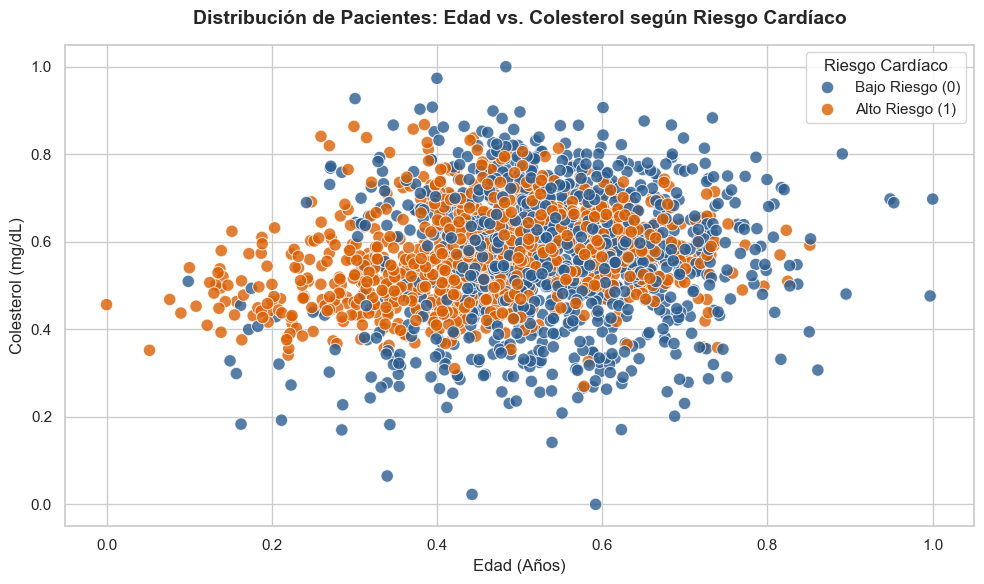

In [49]:
# Configurar un estilo limpio y profesional para publicaciones científicas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Crear el gráfico de dispersión (Scatter Plot)
scatter = sns.scatterplot(
    data=df, 
    x='edad',               # Reemplazar por el nombre exacto de tu columna de edad
    y='colesterol',         # Reemplazar por tu columna de colesterol
    hue='riesgo_cardiaco',  # Variable objetivo que segmenta los colores
    palette={0: '#2b5c8f', 1: '#d95f02'}, # Azul para bajo riesgo, Naranja/Rojo para alto riesgo
    alpha=0.8,
    s=80
)

# Personalización de etiquetas y títulos
plt.title('Distribución de Pacientes: Edad vs. Colesterol según Riesgo Cardíaco', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Colesterol (mg/dL)', fontsize=12)

# Ajustar las etiquetas de la leyenda
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles, ['Bajo Riesgo (0)', 'Alto Riesgo (1)'], title='Riesgo Cardíaco', frameon=True)

# Desplegar el gráfico en el Notebook
plt.tight_layout()
plt.show()

#### Visualización Gráfica del Árbol de Decisión
Aprovechando que la función devuelve el objeto del modelo entrenado y las variables predictoras (`X`), podemos graficar la estructura del árbol generado. Esto permite analizar las reglas lógicas e interrogantes que el algoritmo construye en sus nodos.

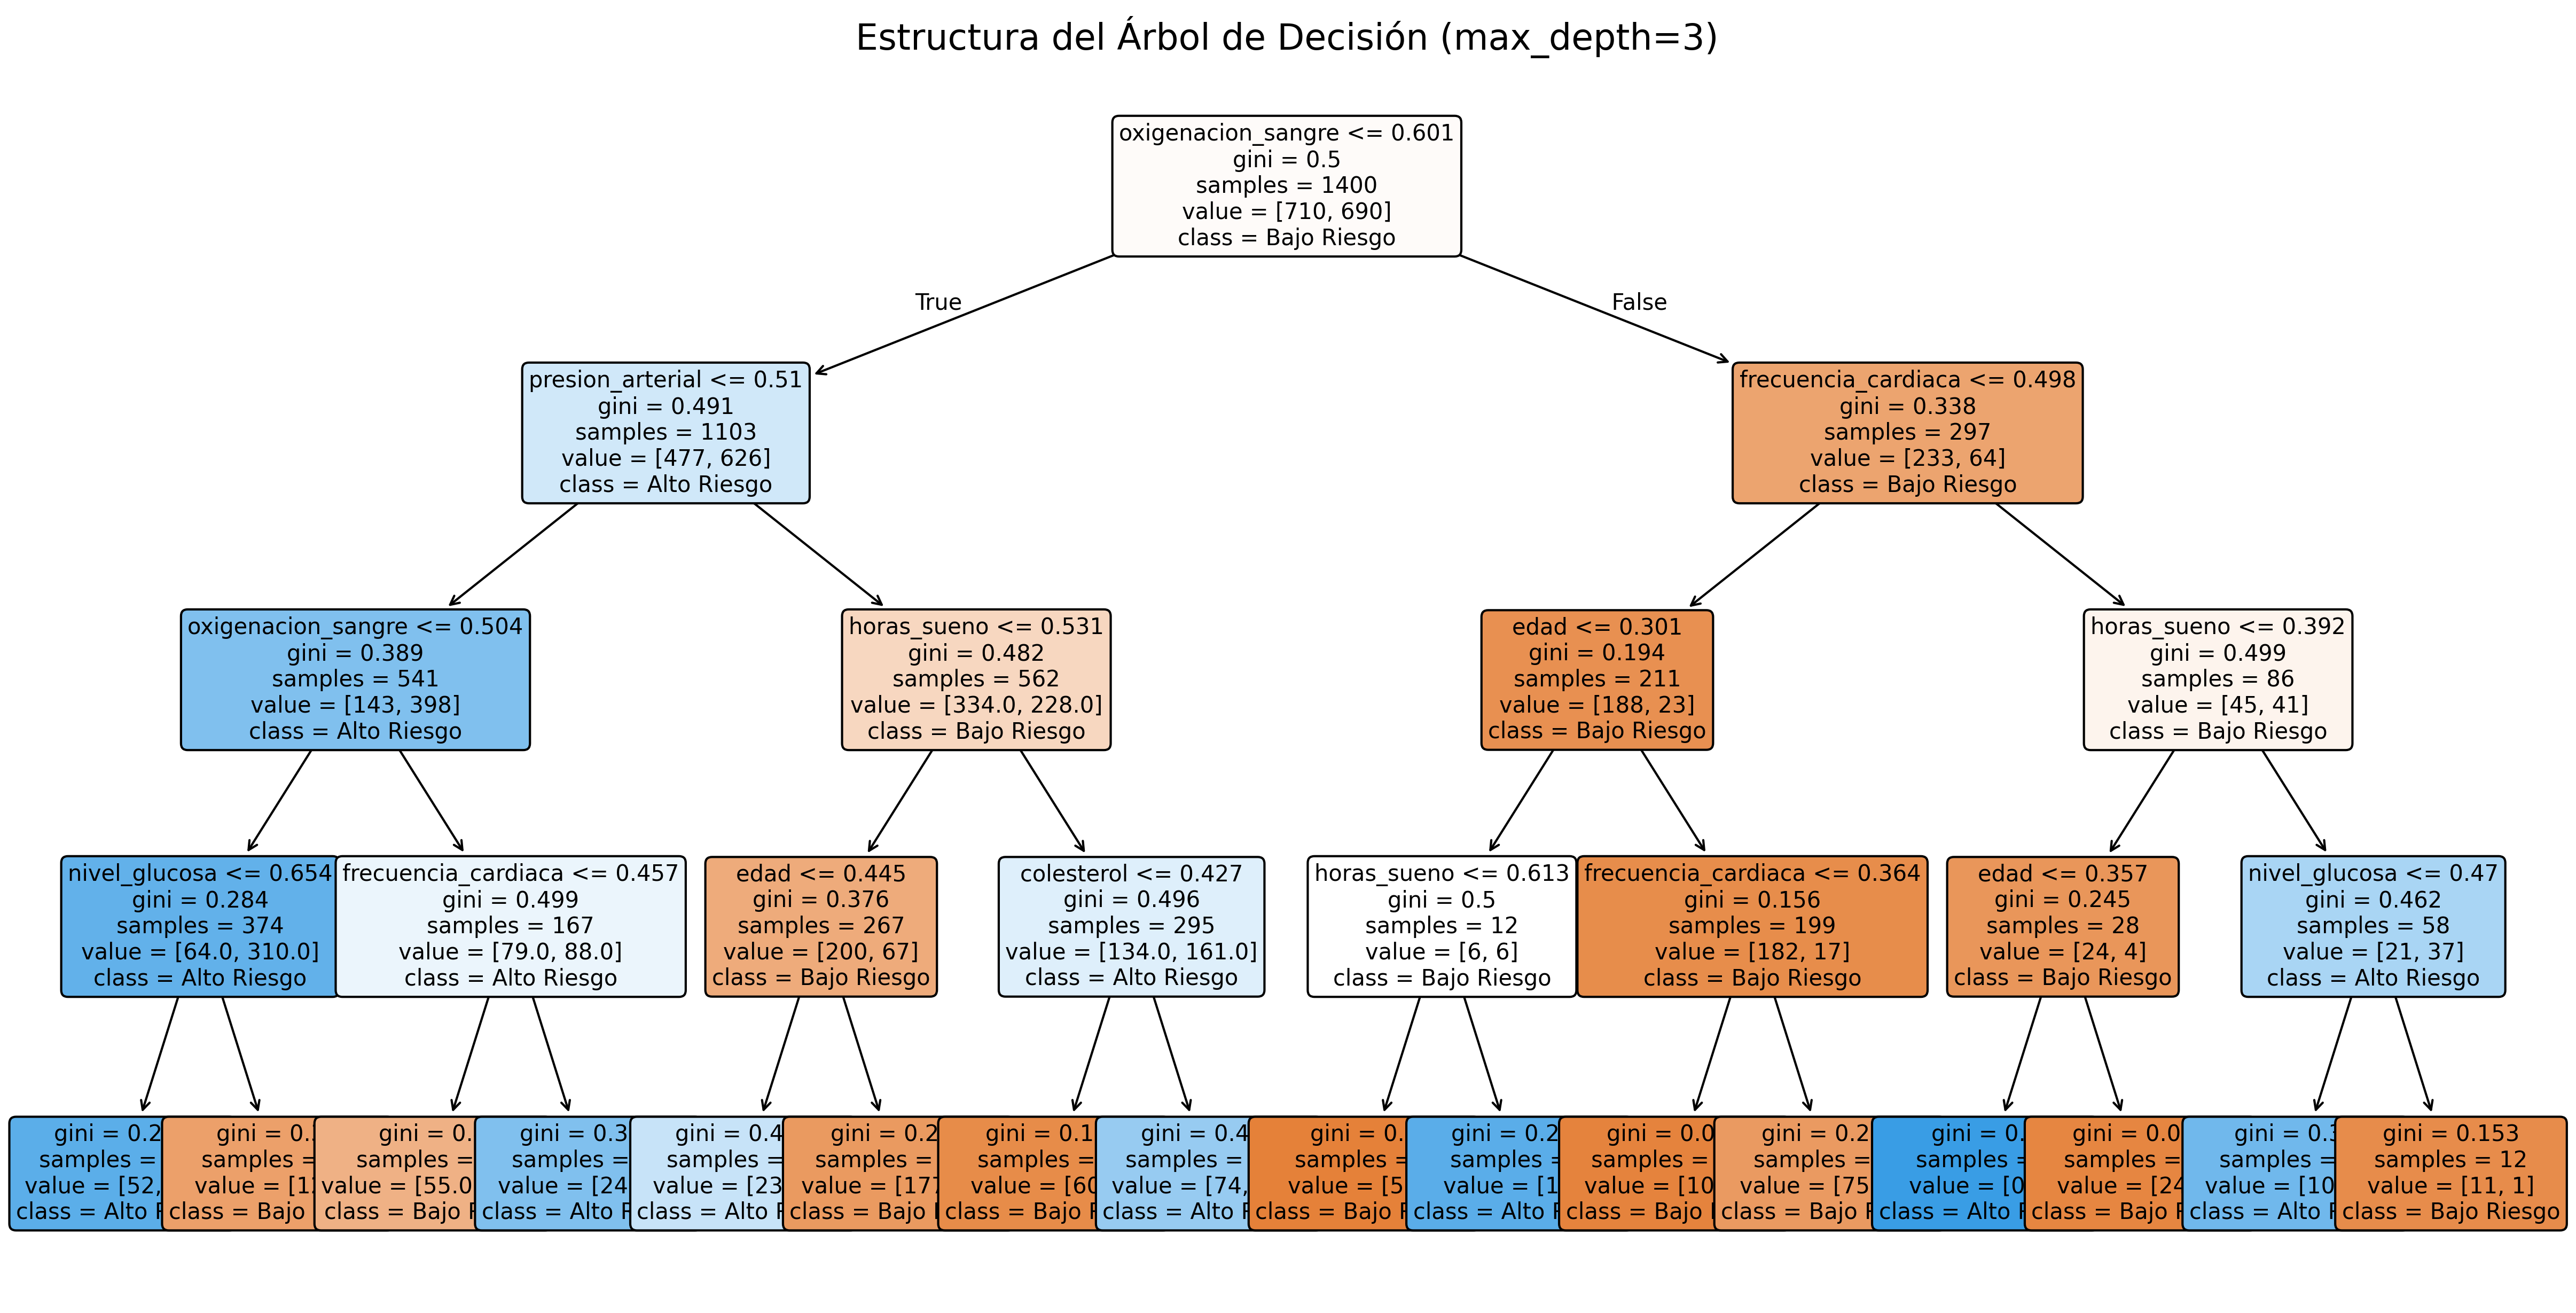

In [48]:
plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=['Bajo Riesgo', 'Alto Riesgo'],   
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Estructura del Árbol de Decisión (max_depth=3)", fontsize=16)
plt.show()